## Coding a Closed Form BS

In [1]:
from scipy.stats import norm
import math
import numpy as np

#Define Standard Normal Distribution

Z=norm(0,1) #A Creating a standard normal distribution

In [2]:
# We require the Stock Price, Time till Maturity, Risk Free inverse Rate, Standard deviation of log returns AND sTRIKE pRICE
# Now for OOPs we have a Class , For the given class there will be the set of attributes whih are the Option Parameters and Finally the Option method which is the Payoff and Pricer 

class Option:
    def __init__(self,S0,K,T,r,sigma):
        self.S0=S0 #The stock Price
        self.K = K #The Strike Price
        self.T = T #Time to Maturity
        self.r = r #Risk Free Interest Rate
        self.sigma = sigma #Volatility of the Stock Price

    def payoff(self):
        return max(self.S0-self.K,0)
    
    def BS_Close_Form(self):
        d_1= (math.log(self.S0/self.K) + (self.r+ (((self.sigma)**2)/2))*self.T)/self.sigma*((self.T)**0.5)
        d_2 = d_1 - self.sigma*((self.T)**0.5)
        Z.cdf(d_1) # The main part
        Z.cdf(d_2)
        return Z.cdf(d_1)*self.S0-Z.cdf(d_2)*self.K*math.e**(self.r**self.T)

    
    


Checking wether the code works

In [3]:
option1=Option(100,150,5,0.05,0.10)
option1.payoff()
option1.BS_Close_Form()

0.05022029257722499

## Coding Monte Carlo
The idea now is to code the Stock Evolution Path obtained from Black Scholes Simulation into a Monte Carlo Process.
- As Monte Carlo says, multiple simulations of Stock SDE will be run and for every simulation, there will be a terminal stock price. 
- The option payoff will be calculated for each simulation from the terminal stock price of that simulation
- Finally the option payoff will be averaged accross simulations and discounted to find the Option Price
- This is known as Risk Neutral Pricing Theory

In [4]:
class MonteCarlo():
    def __init__(self,S_0,K,T,r,sigma,M,N): #Here M is the number of Monte Carlo simulations and N is the number of steps
        self.S_0=S_0 #The stock Price
        self.K = K #The Strike Price
        self.T = T #Time to Maturity
        self.r = r #Risk Free Interest Rate
        self.sigma = sigma #Volatility of the Stock Price\
        self.M = M # The Number of Monte Carlo Simulation
        self.N = N # The Number of Steps

    # Step 1: Coding One Simulation 
        
    def Sim(self):
        Del_T=self.T/self.N # This is dt
        S0 = self.S_0 #Initial Stock Price
        S=[S0]
        n=self.N #Temporary Assignment to ensure N is not altered
        for i in range(0,n):
            Z=np.random.normal(0,1) #The Standard Normal Process
            S.append(S[i]*(1+(self.r)*Del_T+(self.sigma)*((Del_T)**0.5)*Z))
        return max(S[n-1]-self.K,0) #The payoff 
    
    # Step 2: Running Monte Carlo (The idea here is since we already have coded one simulation we will use the above function Sim , Note Monte Carlo is average of al the Sims)

    def MC(self):
        Sim_List=[]
        for i in range(0,self.M):
            Sim_List.append(self.Sim()) #Note the self.Sim() is the same as self.(any other attribute), the reason being for MC, the attribute is Sim in itself, Hence self.Sim()
        return math.e**(-self.r*self.T)*(sum(Sim_List)/self.M) #The expected Payoff
    



Checking whether the code works

In [5]:
Sim1=MonteCarlo(100,150,5,0.05,0.10,200,9)
Sim1.Sim()
Sim1.MC()

1.1178618000876837

## Coding the Geeks

In [6]:
class Geeks():
    def __init__(self,S0,K,T,r,sigma):
        self.S0=S0 #The stock Price
        self.K = K #The Strike Price
        self.T = T #Time to Maturity
        self.r = r #Risk Free Interest Rate
        self.sigma = sigma #Volatility of the Stock Price

    def Delta(self): # Change of Call Price due to change in Stock
        d_1= (math.log(self.S0/self.K) + (self.r+ (((self.sigma)**2)/2))*self.T)/self.sigma*((self.T)**0.5)
        d_2 = d_1 - self.sigma*((self.T)**0.5)
        Z.cdf(d_1) # The main part
        Z.cdf(d_2) 
        return Z.cdf(d_1) 
        
    def Gamma(self): # Change of Delta due to change in Stock
        d_1= (math.log(self.S0/self.K) + (self.r+ (((self.sigma)**2)/2))*self.T)/self.sigma*((self.T)**0.5)
        d_2 = d_1 - self.sigma*((self.T)**0.5)
        Z.pdf(d_1) # The main part
        Z.pdf(d_2) 
        return Z.pdf(d_1)/((self.S0)*(self.sigma)*((self.T)**0.5))
    
    def Vega(self): # Change of Stock Price due to change in Volatility
        d_1= (math.log(self.S0/self.K) + (self.r+ (((self.sigma)**2)/2))*self.T)/self.sigma*((self.T)**0.5)
        d_2 = d_1 - self.sigma*((self.T)**0.5)
        Z.pdf(d_1) # The main part
        Z.pdf(d_2) 
        return Z.pdf(d_1)*(self.S0)*(self.sigma)*((self.T)**0.5)
    
    def Theta(self): # Change of Stock Price due to Time of Expire
        d_1= (math.log(self.S0/self.K) + (self.r+ (((self.sigma)**2)/2))*self.T)/self.sigma*((self.T)**0.5)
        d_2 = d_1 - self.sigma*((self.T)**0.5)
        Z.pdf(d_1) # The main part
        Z.cdf(d_2)
        return -Z.pdf(d_1)*(self.S0)*(self.sigma)/2*((self.T)**0.5) - self.r*self.K*math.e**(-self.r*self.T)*(Z.cdf(d_2))
    
    def Row(self):
        d_1= (math.log(self.S0/self.K) + (self.r+ (((self.sigma)**2)/2))*self.T)/self.sigma*((self.T)**0.5)
        d_2 = d_1 - self.sigma*((self.T)**0.5)
        Z.pdf(d_1) # The main part
        Z.cdf(d_2)
        return self.r*self.T*math.e**(-self.r*self.T)*(Z.cdf(d_2))
    
    def All_Geeks(self):
        print (f"The Delta of the Call Option is {self.Delta()}")
        print (f"The Gamma of the Call Option is {self.Gamma()}")
        print (f"The Vega of the Call Option is {self.Vega()}")
        print (f"The Theta of the Call Option is {self.Theta()}")
        print (f"The Row of the Call Option is {self.Row()}")



Checking wether the code works

In [7]:
Geeks(100,150,5,0.05,0.10).All_Geeks()

The Delta of the Call Option is 0.0017654450683922184
The Gamma of the Call Option is 0.0002531499161349202
The Vega of the Call Option is 0.1265749580674601
The Theta of the Call Option is -0.06820654734592713
The Row of the Call Option is 0.00016396894373990224


## The Key Takeaway of the project are the following
- Since Monte Carlo depends on the number of simulation, Monte Carlo Answer produces a Path Dependent Option Price that changes with number of simulations, The Black Scholes produces a closed form Solution or Option Price that is not dependent with the number of paths
- Though in the context of Vanilla Options and Stock Price following a log normal distribution, Black Scholes is correct solution, However when Stock Price has additional randomness like jumpm and heavy tails, Closed Form Solutions fail and Monte Carlo methods take place
- Though in this project Monte Carlo simulation has been done of Stock following BS SDE, when Stock do not follow log normal distribution, then Monte Carlo simulation of Stock following Heston or Merton SDE (depending on the behaviour of observed Stock Price) is taken and Closed form solutions like Black Scholes falls flat

## Volatility Smile

In [8]:
#Importing necessary Libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm as Z

N_prime = norm.pdf
N = norm.cdf

In [9]:
# Loading Nvidia Ticker

nvda =yf.Ticker("NVDA")

In [10]:
# Getting available expiries
expiries = nvda.options
print(expiries)

('2026-06-22', '2026-06-24', '2026-06-26', '2026-06-29', '2026-07-01', '2026-07-02', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [11]:
## Choosing Expiry of 3 months or June 18, 2026 

expiry = '2026-09-18'

# Get option chain for that expiry date
opt_chain = nvda.option_chain(expiry)

calls = opt_chain.calls 
puts = opt_chain.puts

price = 210.69 #Spot Price of the Stock as on 21-06-2026

print(calls.head())

        contractSymbol             lastTradeDate  strike  lastPrice     bid  \
0  NVDA260918C00005000 2026-06-18 14:24:34+00:00     5.0     204.90  201.00   
1  NVDA260918C00010000 2026-04-15 16:41:46+00:00    10.0     188.72  212.75   
2  NVDA260918C00015000 2026-06-16 17:40:39+00:00    15.0     194.35  191.00   
3  NVDA260918C00020000 2026-06-16 17:40:38+00:00    20.0     189.43  186.00   
4  NVDA260918C00025000 2026-05-11 14:51:49+00:00    25.0     196.00  182.60   

      ask    change  percentChange  volume  openInterest  impliedVolatility  \
0  209.70  2.199997       1.085346       4            43           8.199224   
1  220.00  0.000000       0.000000       2            19           0.000000   
2  199.60  0.000000       0.000000      30            52           4.179692   
3  194.65  0.000000       0.000000       5            82           3.624024   
4  186.75  0.000000       0.000000       1           933           2.378910   

   inTheMoney contractSize currency  
0        Tru

In [12]:
## Cleaning Call Data 
calls = calls[['contractSymbol', 'strike', 'lastPrice','bid', 'ask', 'volume','openInterest', 'impliedVolatility']]

calls.dropna(inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_6560\1294115870.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls.dropna(inplace=True)


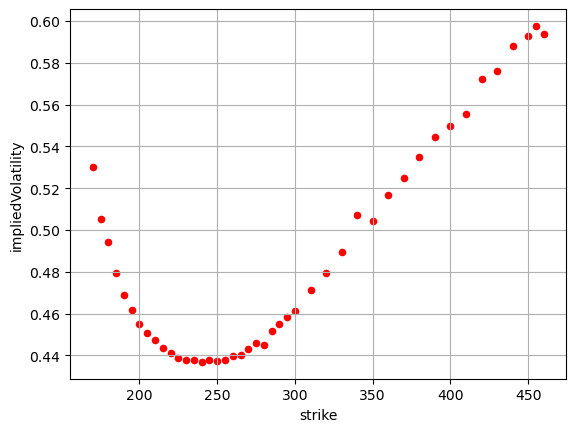

In [13]:

## Plotting Implied Volatility along with smile behaviour

calls = calls[calls['impliedVolatility'] > 0]
calls["strike"] = calls["strike"].astype(float)
calls = calls[
    calls["strike"] > 210.69 * 0.8
]  # We will only consider those options within a certain range of the current price
calls = calls[
    calls["strike"] < 210.69 * 5
]  # One reason for this is that it is precisely those options that are most often traded.



calls.plot(kind="scatter", x="strike", y="impliedVolatility", color="red")
plt.grid()
plt.show()

## Applying the Newton Rhapson Method for Implied Volatility Calculation

In [14]:
class NewRhap_Vol(): #The idea is Option and Geeks are required for Vega and Black Schole Pricing
    def __init__(self,price,S0,K,T,r):
        self.price=price #This is the Empirical Call Price
        self.S0=S0 #This is the Spot Price
        self.K=K #This is the Strike Price
        self.T=T #This is the Time to Expiry
        self.r=r #This is the Risk Free Rate

    def BS_Close_Form(self,sigma): #To note one thing critically that sigma is jsut a parameter for this
        d_1= (math.log(self.S0/self.K) + (self.r+ (((sigma)**2)/2))*self.T)/(sigma*((self.T)**0.5))
        d_2 = d_1 - sigma*((self.T)**0.5)
        return Z.cdf(d_1)*self.S0-Z.cdf(d_2)*self.K*math.e**(-self.r*self.T)
    
    def Vega(self,sigma): # Change of Stock Price due to change in Volatility
        d_1= (math.log(self.S0/self.K) + (self.r+ (((sigma)**2)/2))*self.T)/(sigma*((self.T)**0.5))
        d_2 = d_1 - sigma*((self.T)**0.5)
        return Z.pdf(d_1)*(self.S0)*((self.T)**0.5)

    def NewtonRhapson(self,sigma): #To note one thing critically that sigma is not just a parameter for this, but the initial Implied Volatility
        for i in range(0,500):
            if self.Vega(sigma) < 1e-6:
                return None   # or break
            else:
                sigma=sigma-((self.BS_Close_Form(sigma)-self.price)/self.Vega(sigma))
        return sigma


Dryrunning the code

In [15]:
NewRhap_Vol(40,100,150,5,0.05).NewtonRhapson(0.10)

0.525441955077308

In [16]:
#Now the key is to apply this for every entry in the chain in the earlier created calls Dataset that followed the Strike condition
calls[(calls['strike'] > 172.93 * 0.8) & (calls['strike'] <172.93 * 5)].shape[0]

44

In [17]:
calls

,contractSymbol,strike,lastPrice,bid,ask,volume,openInterest,impliedVolatility
33,NVDA260918C00170000,170.0,46.37,44.50,46.50,745,9788,0.530400
34,NVDA260918C00175000,175.0,42.18,40.70,42.10,398,8851,0.505376
35,NVDA260918C00180000,180.0,38.37,36.65,38.20,234,16532,0.494451
36,NVDA260918C00185000,185.0,34.63,33.00,34.30,171,10686,0.479253
37,NVDA260918C00190000,190.0,30.85,29.90,30.70,533,104768,0.468755
38,NVDA260918C00195000,195.0,27.47,26.70,27.40,62,12880,0.461736
39,NVDA260918C00200000,200.0,24.40,23.75,24.30,941,35193,0.454900
40,NVDA260918C00205000,205.0,21.47,21.10,21.50,470,8163,0.450628
41,NVDA260918C00210000,210.0,18.70,18.30,18.95,4483,35183,0.447302
42,NVDA260918C00215000,215.0,16.65,15.95,16.60,1170,12241,0.443792


In [18]:
IV = []

for row in calls.itertuples():
    sigma_init = 0.2 + 0.5 * abs(np.log(210.69 / row.strike)) #The initial guess for OTM and ITM = sigma(initial guess,atm)-|log(S/K)| has been decided since vega -> 0 for OTM and ITM quickly 
    
    iv_est = NewRhap_Vol(
        row.lastPrice,
        210.69 ,
        row.strike,
        0.25,
        0.05
    ).NewtonRhapson(sigma_init)

    bs_est = NewRhap_Vol(
        row.lastPrice,
        210.69,
        row.strike,
        0.25,
        0.05
    ).BS_Close_Form(iv_est)


    IV.append({
        'Strike': row.strike,
        'ActualIV': row.impliedVolatility,
        'EstimatedIV': iv_est,
        'BS IV Price':bs_est,
        'Actual Price':row.lastPrice
    })

IV = pd.DataFrame(IV)

In [19]:
IV

,Strike,ActualIV,EstimatedIV,BS IV Price,Actual Price
0,170.0,0.530400,0.455255,46.37,46.37
1,175.0,0.505376,0.444703,42.18,42.18
2,180.0,0.494451,0.443203,38.37,38.37
3,185.0,0.479253,0.437911,34.63,34.63
4,190.0,0.468755,0.426181,30.85,30.85
5,195.0,0.461736,0.421034,27.47,27.47
6,200.0,0.454900,0.418642,24.40,24.40
7,205.0,0.450628,0.414233,21.47,21.47
8,210.0,0.447302,0.408409,18.70,18.70
9,215.0,0.443792,0.414522,16.65,16.65


#Since IV can be non empty, printing entries with non empty values

In [20]:
IV[IV["EstimatedIV"].notna()]

,Strike,ActualIV,EstimatedIV,BS IV Price,Actual Price
0,170.0,0.530400,0.455255,46.37,46.37
1,175.0,0.505376,0.444703,42.18,42.18
2,180.0,0.494451,0.443203,38.37,38.37
3,185.0,0.479253,0.437911,34.63,34.63
4,190.0,0.468755,0.426181,30.85,30.85
5,195.0,0.461736,0.421034,27.47,27.47
6,200.0,0.454900,0.418642,24.40,24.40
7,205.0,0.450628,0.414233,21.47,21.47
8,210.0,0.447302,0.408409,18.70,18.70
9,215.0,0.443792,0.414522,16.65,16.65


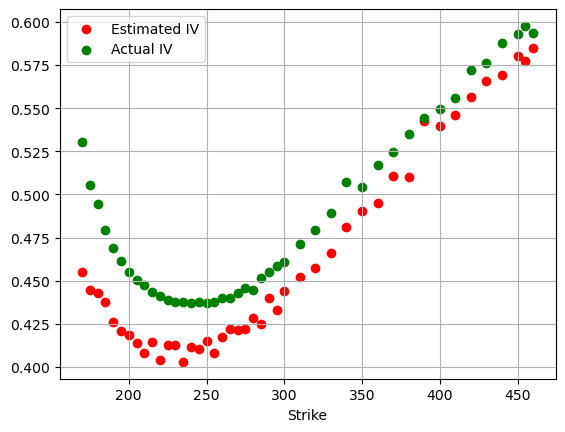

In [21]:
plt.scatter(IV["Strike"], IV["EstimatedIV"], color="red",label='Estimated IV')
plt.scatter(IV["Strike"], IV["ActualIV"], color="green",label='Actual IV')
plt.xlabel("Strike")
plt.legend()
plt.grid()
plt.show()

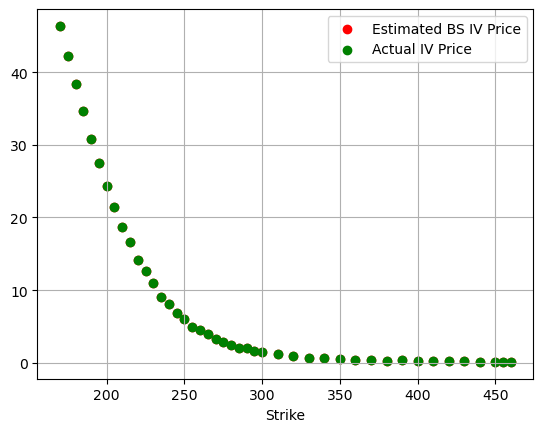

In [22]:
plt.scatter(IV["Strike"], IV["BS IV Price"], color="red",label='Estimated BS IV Price')
plt.scatter(IV["Strike"], IV["Actual Price"], color="green",label='Actual IV Price')
plt.legend()
plt.xlabel("Strike")
plt.grid()
plt.show()

## Key Outcome of this work
1) For Every Strike Initial Implied Volatility needs to be different since same Implied Volatility for evert strike might fail for OTM and ITM options
2) Black Scholes underestimates heavily actual option price for OTM options and ITM options but performs reasonably good for ATM options
3) Since we are not using Actual IV in Estimated IV calculation, the divergence between estimated IV and actual IV is primarily due to numerical issues (Newton–Raphson, low Vega), along with input mismatches and noise in market data 


Implementing CEV model

Obviously, as the option is more ITM, the premium of the call option increases. The question at this point is, can we replicate these prices with the CEV model?


## 2. Implementing CEV Model with Known Parameters

Dynamics of CEV Model:

$dS = \mu(S,t) dt + \sigma(S, t)dZ$, with:

$\sigma(S, t) = \sigma S^{\beta/2}$, $0\leq \beta < 2$

$\mu(S, t) = rS$

\
Of course, an important assumption is going to be the choice of parameters $σ$ and and $\beta$. We will refine these choices later, but so far, let's just assume some given parameters. Later on, we will calibrate these parameters to market prices. For now:

- $\sigma = 0.29$
- $\beta = 1.15$

Also, let's assume a value for the risk-free rate:

- $r=0.05$

### Setting up the Initial Parameter of CEV

In [23]:
import numpy as np
from scipy.stats import ncx2
from sklearn.metrics import mean_squared_error

# Setting Initi
# Variables

S0=210.69
r=0.05
Td=0.25
sigma=0.29
beta=1.15

### Coding the Closed Form CEV

In [24]:
import math
from scipy.stats import ncx2

class CEV():
    def __init__(self, S0, t, K, sigma, beta, r):
        self.S0 = S0      # Spot price
        self.t = t        # Time to expiry
        self.K = K        # Strike
        self.sigma = sigma
        self.beta = beta
        self.r = r

    def CEVprice(self):
        S0 = self.S0
        t = self.t
        K = self.K
        sigma = self.sigma
        beta = self.beta
        r = self.r

        # Avoid division issues when beta ~ 2
        if abs(2 - beta) < 1e-8:
            raise ValueError("Beta too close to 2 (Black-Scholes limit).")

        zb = 2 + 2 / (2 - beta)

        kappa = (2 * r) / (
            sigma**2 * (2 - beta) * (math.exp(r * (2 - beta) * t) - 1)
        )

        x = kappa * (S0 ** (2 - beta)) * math.exp(r * (2 - beta) * t)
        y = kappa * (K ** (2 - beta))

        call_price = (
            S0 * (1 - ncx2.cdf(2 * y, zb, 2 * x))
            - K * math.exp(-r * t) * ncx2.cdf(2 * x, zb - 2, 2 * y)
        )

        return call_price
    



In [25]:
CEV(S0, 0.25, 100, 0.29, 1.15, 0.05).CEVprice()

111.93221995061185

### Applying the CEV to the Nvidia data chain

In [26]:
CEVP=[]

for row in calls.itertuples():
    call_price=CEV(S0, Td, row.strike, sigma, beta, r).CEVprice()

    CEVP.append({
        'Strike': row.strike,
        'ActualIV': row.impliedVolatility,
        'Actual Price':row.lastPrice,
        'Call Price CV':call_price
    })

CEVP=pd.DataFrame(CEVP)

Text(0, 0.5, 'Call Price CV, Actual Price')

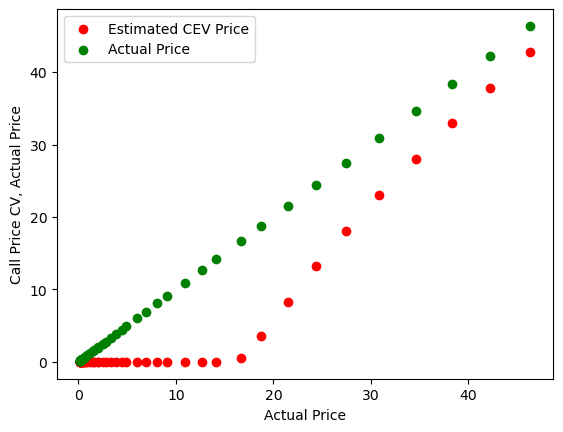

In [27]:
plt.scatter(x=CEVP['Actual Price'],y=CEVP['Call Price CV'],color="red",label='Estimated CEV Price')
plt.scatter(x=CEVP['Actual Price'],y=CEVP['Actual Price'],color="green",label='Actual Price')
plt.legend()
plt.xlabel('Actual Price')
plt.ylabel('Call Price CV, Actual Price')

## Calibrating the CEV Model

In [28]:
### Importing the libraries

from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

In [29]:
def error(params):
    sigma = params[0]
    beta = params[1]

    modelprices = CEV(S0, 0.25, CEVP['Strike'], sigma, beta, 0.05).CEVprice()  # Model price calculation using your C function
    realprices=CEVP[['Actual Price']]


    mse = mean_squared_error(modelprices, realprices)
    return mse  # We want to minimize this error

bnds = ((0.2, 2), (0, 1.9))  # Example bounds, adjust as necessary
init_guess = (0.29, 1.15)

# Perform the optimization
res = minimize(error, init_guess, bounds=bnds, options={'disp': True})

C:\Users\Asus\AppData\Local\Temp\ipykernel_6560\1023892728.py:16: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(error, init_guess, bounds=bnds, options={'disp': True})


## Calibrated Alpha and Beta

In [30]:
res.x[0], res.x[1]

(0.6909741704415986, 1.8132513847837424)

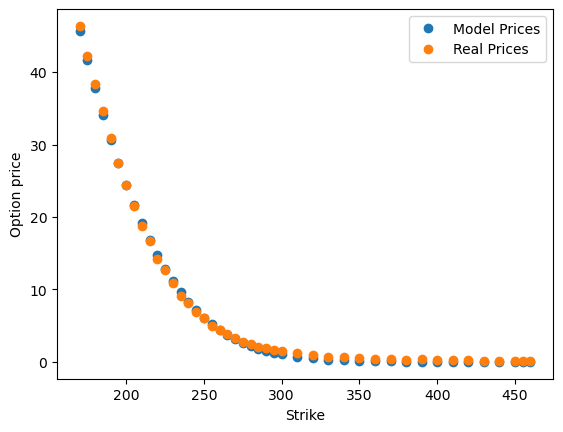

In [31]:
modelprices=CEV(S0, 0.25, CEVP['Strike'], res.x[0], res.x[1], 0.05).CEVprice()
realprices = CEVP[['Actual Price']]
plt.plot(CEVP['Strike'],modelprices,'o', label='Model Prices')
plt.plot(CEVP['Strike'],realprices,'o', label='Real Prices')
plt.xlabel('Strike')
plt.ylabel('Option price')
plt.legend()

In [32]:
residuals=CEV(S0, 0.25, CEVP['Strike'], res.x[0], res.x[1], 0.05).CEVprice()-CEVP['Actual Price']

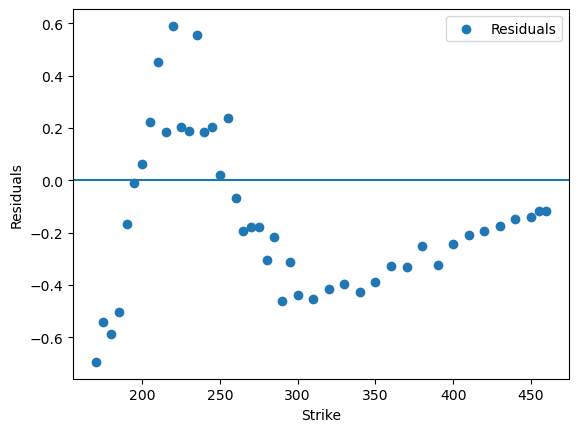

In [33]:
plt.scatter(CEVP['Strike'],residuals,label='Residuals')
plt.axhline(0)
plt.xlabel('Strike')
plt.ylabel('Residuals')
plt.legend()

The value of $σ$ and and $\beta$ after alpha and beta calibration are as follows:

- $\sigma = 0.69$
- $\beta = 1.81$

This is in accordance with Market Expectation and since $\beta<2$ , this means stock evolution follows a GBM (Geometric Brownian Motion Process) and Stock follows a log normal distribution

### Plotting Evolution of Volatility with respect to hypothetical Stock Prices

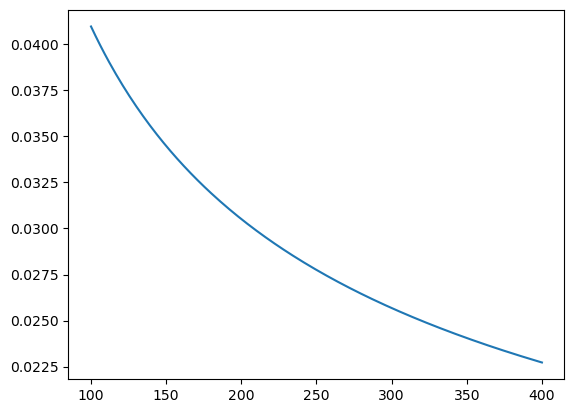

In [34]:
S = np.linspace(100,400,200)

sigma_loc = sigma * S**(beta/2 - 1)

plt.plot(S,sigma_loc)

## Implementing a Heston Model

## **1. Simulating the Heston Model in Python**

We can simulate stock price paths under Heston model dynamics with the following two equations:
$$
\begin{equation*} 
    S_t = S_{t-1} e^{\left( r - \frac{\nu_t}{2} \right) dt +  \sqrt{\nu_t} dZ_1}
\end{equation*}
$$
$$
\begin{equation*} 
    \nu_t = \nu_{t-1} + \kappa \left( \theta - \nu_{t-1} \right) dt + \sigma \sqrt{\nu_{t-1}}dZ_2
\end{equation*}
$$


We will start by coding the **stochastic volatility function**, $\nu_t$:

*Notice how we calculate $\nu_t$ as the maximum between the $\nu_t$ expression above and 0. This is to ensure that we do not get a negative number here because of the random process. Obviously, it does not make any sense whatsoever to have negative variance!*

- First, **stochastic volatility**:

In [35]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M  # T = maturity, M = number of time steps
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)  # Sqrt of dt
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

- Second, **underlying stock price** path based on stochastic vol:

In [36]:
def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M+1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M+1, 1):
        ran = np.dot(cho_matrix, rand[:,t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1]) * ran[row] * sdt)

    return S

- Third, our function to **generate random numbers** following a standard normal:

In [37]:
np.random.seed(42)

In [38]:
def random_number_gen(M, I):
    rand = np.random.standard_normal((2, M+1, I))
    return rand

In [39]:
v0 = 0.04
kappa_v = 2
sigma_v = 0.3
theta_v = 0.04
rho = -0.9

S0 = 210.69  # Current underlying asset price
r = 0.05  # Risk-free rate
M0 = 500   # Number of time steps in a year
T = 0.25  # Number of years
M = int(M0*T) # Total time steps
I = 100  # Nomber of simulations
dt = T/M  # Length of time step


In [40]:
# Generating random numbers from standard normal
rand = random_number_gen(M, I)
np.random.seed(42)

# Covariance Matrix
covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho]
covariance_matrix[1] = [rho, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

In [41]:
# Volatility process paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)

# Underlying price process paths
S = Heston_paths(S0, r, V, 0, cho_matrix)

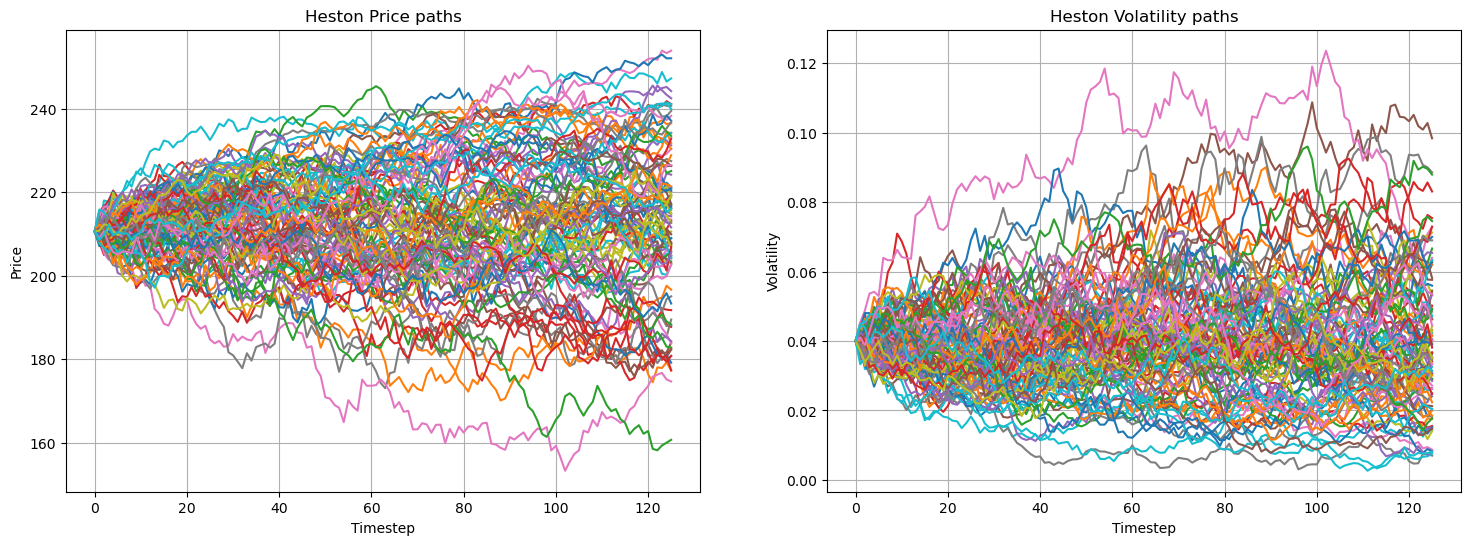

In [42]:
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V)), V[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")


plot_paths(100)

The payoffs and current price of a European call option with the following characteristics:

- $T=1$ year
- $K = strike$
- $r=0.05$
- $S_t \sim$ Heston dynamics

The price of the Call option will be given by:

$$
C_0 = e^{-rT}E\left( S_T - K \right)^+
$$

which, using Monte-Carlo, we can code into:

In [43]:
def heston_call_mc(S, K, r, T, t):
    payoff = np.maximum(0, S[-1, :] - K)

    average = np.mean(payoff)

    return np.exp(-r * (T - t)) * average

### Checking the Code for one Strike

In [44]:
print("European Call Price under Heston: ", heston_call_mc(S, 70, r, T, 0))

European Call Price under Heston:  140.98853438683136


Appying the code to Entire 3 month Option chain 

In [45]:
Heston=[]

for row in calls.itertuples():
    call_price=heston_call_mc(S, row.strike, r, T, 0)
    

    Heston.append({
        'Strike': row.strike,
        'ActualIV': row.impliedVolatility,
        'Actual Price':row.lastPrice,
        'Call Price Heston':call_price
    })

Heston=pd.DataFrame(Heston)

In [46]:
Heston

,Strike,ActualIV,Actual Price,Call Price Heston
0,170.0,0.530400,46.37,42.322892
1,175.0,0.505376,42.18,37.437650
2,180.0,0.494451,38.37,32.660127
3,185.0,0.479253,34.63,28.153611
4,190.0,0.468755,30.85,23.918884
5,195.0,0.461736,27.47,19.868800
6,200.0,0.454900,24.40,15.950903
7,205.0,0.450628,21.47,12.171368
8,210.0,0.447302,18.70,9.104843
9,215.0,0.443792,16.65,6.552721


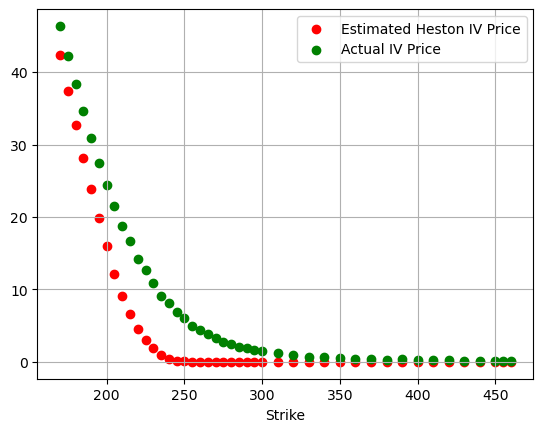

In [47]:
plt.scatter(Heston["Strike"], Heston["Call Price Heston"], color="red",label='Estimated Heston IV Price')
plt.scatter(Heston["Strike"], Heston["Actual Price"], color="green",label='Actual IV Price')
plt.legend()
plt.xlabel("Strike")
plt.grid()
plt.show()

## Calibrating the Heston Model

In [48]:
import numpy as np
from scipy.optimize import minimize

# --- 1. Monte Carlo Pricer (Euler Discretization) ---
def heston_mc_price(S0, K, T, r, kappa, theta, sigma, rho, v0, num_paths=5000, num_steps=100):
    dt = T / num_steps
    sqrt_dt = np.sqrt(dt)
    
    # Initialize arrays
    V = np.full(num_paths, v0)
    S = np.full(num_paths, S0)
    
    # Correlated Random Walks
    for t in range(num_steps):
        Z1 = np.random.standard_normal(num_paths)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(num_paths)
        
        # Variance process (Euler step)
        V_next = V + kappa * (theta - V) * dt + sigma * np.sqrt(np.maximum(V, 0)) * sqrt_dt
        V = np.maximum(V_next, 0)  # Truncate at zero to avoid negative variance
        
        # Stock price process (Euler step)
        S = S * np.exp((r - 0.5 * V) * dt + np.sqrt(V) * sqrt_dt * Z1)
        
    # Payoff for European Call
    payoff = np.maximum(S - K, 0)
    return np.exp(-r * T) * np.mean(payoff)

# --- 2. Objective Function for Calibration ---
def objective_function(params, market_prices, S0, K_list, T_list, r):
    kappa, theta, sigma, rho, v0 = params
    error_sum = 0
    
    for i, K in enumerate(K_list):
        T = T_list[i]
        model_price = heston_mc_price(S0, K, T, r, kappa, theta, sigma, rho, v0)
        market_price = market_prices[i]
        error_sum += (model_price - market_price) ** 2
        
    return error_sum

# --- 3. Calibration Execution ---
def calibrate_heston(market_prices, S0, K_list, T_list, r):
    # Initial guesses: [kappa, theta, sigma, rho, v0]
    initial_guess = [2.0, 0.04, 0.3, -0.5, 0.04]
    
    # Boundaries to keep parameters in valid domains (e.g., v0 > 0, -1 < rho < 1)
    bounds = [(0.01, 10.0), (0.001, 1.0), (0.01, 2.0), (-0.99, 0.99), (0.001, 1.0)]
    
    result = minimize(
        objective_function, 
        initial_guess, 
        args=(market_prices, S0, K_list, T_list, r), 
        bounds=bounds, 
        method='L-BFGS-B'
    )
    
    return result.x

## Calibrating Heston Model with Nvidia Option Chain Data

In [67]:
market_prices=heston_call['lastPrice'].values
K_list=heston_call['strike'].values
T_list=heston_call['T_list'].values
r=0.05
calibrate_heston(market_prices, S0, K_list, T_list, r)

array([ 2.00000092,  0.04000005,  0.30000001, -0.49999984,  0.04000012])

The value of $\kappa$, $\theta$ $\sigma$ $\rho$ $\v0$ after alpha and beta calibration are as follows: 

- $\kappa$ = 2.00000092
- $\theta$ = 0.04000005
- $\sigma$ = 0.30000001
- $\rho$ = -0.49999984
- $\v0$ = 0.04000012


However Heston Model using Monte Carlo takes an abnormal level of time for calibration and hence should be avoided 